# **How Do Weather and Snow Conditions Affect Solar Energy Production?**

Sam Keller, Anne Mara, and Anna Simonelli

# **Introduction**

Solar energy is an increasingly important renewable resource, but its efficiency is dependent on environmental conditions. Unlike traditional energy sources, solar production varies from day to day based on factors such as cloud cover, atmospheric conditions, and seasonal changes. In regions with significant winter weather, additional factors like snowfall and snowpack may further influence how much energy solar panels are able to generate.

A common assumption is that clear skies always lead to higher solar output, while precipitation and snow reduce production. However, some effects are less obvious. For example, while snowfall may block sunlight, snow on the ground could also reflect light and potentially increase solar exposure. This raises the question of how different weather conditions interact to influence solar energy production in practice.

The dataset used in the project was originally collected by a past student and contains daily observations from 2017 to 2023. It combines four sources of data: solar energy production (measured every 15 minutes and aggregated to daily totals), weather conditions, precipitation records, and solar positioning data. After cleaning and merging, the dataset includes variables such as cloud cover (minimum, maximum, and spread), humidity, barometric pressure, rainfall and precipitation totals, snowfall, snowpack depth, temperature, and solar-related measures like sunrise, sunset, and solar angles.

Using this dataset, we aim to better understand how environmental conditions influence solar energy production. Specifically, we investigate the following questions:


1. How do atmospheric conditions (cloud cover, humidity, precipitation, and barometric pressure) affect solar energy production?

2. How much does cloud cover reduce daily solar energy production?

3. How do snowfall and snowpack depth impact solar energy production?

4. Which weather variable has the strongest relationship with solar energy output?


## Imports

In [1]:
# import packages
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import tree, ensemble
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [2]:
# import the data
base_url = "https://raw.githubusercontent.com/aemara04/DataScience_FinalProject/main/Data/"

precipitation = pd.read_csv(base_url + "precipitation.csv")
sun = pd.read_csv(base_url + "sun.csv")
weather = pd.read_csv(base_url + "weather.csv")
solar = pd.read_csv(base_url + "solar.csv")

# **Data Cleaning**

In [3]:
# making precipitation's "Date" lowercase to match all datasets
precipitation.rename(columns={"Date": "date"}, inplace=True)

# convert dates to datetime objects
weather['date'] = pd.to_datetime(weather['date'])
precipitation['date'] = pd.to_datetime(precipitation['date'])
sun['date'] = pd.to_datetime(sun['date'])
solar['date'] = pd.to_datetime(solar['date']).dt.normalize()

#### Convert columns to numeric

In [4]:
cols_to_convert = ['Precip in.', '24-hr Snowfall in.', 'Snowpack Depth in.']
for col in cols_to_convert:
    precipitation[col] = pd.to_numeric(precipitation[col], errors='coerce')

#### Aggregate solar values
Precipatation, weather, and sun are all measured daily, but solar is measured every 15 minutes. We are going to aggregate the solar data to be a daily sum

In [5]:
# aggregate values
solar_daily = (
    solar
    .groupby('date', as_index=False)['value']
    .sum()
    .rename(columns={'value': 'solarDailyTotal'})
)

#### Merging the datasets

We merged the four data sets into one dataset based on the date variable

In [6]:
# merging the four solar datasets
solar_power = (
    solar_daily
    .merge(weather, on='date', how='inner')
    .merge(precipitation, on='date', how='inner')
    .merge(sun, on='date', how='inner')
)

#### Rename columns

In [7]:
# renaming long column names to shorter names for simplicity
solar_power = (
    solar_power
    .rename(
        columns = {
            'Precip in.': 'precip',
            '24-hr Snowfall in.': 'snowfall',
            'Snowpack Depth in.': 'snowpack',
        }
    )
)

#### Feature Engineering

In [8]:
# tells us the spread of the clouds that day (highest position clouds - lowest position clouds)
solar_power['cloudSpread'] = solar_power['cloudMax'] - solar_power['cloudMin']
# gets averages for humidity and barometric pressure to avoid multicollinearity issues
solar_power['humidityAvg'] = (solar_power['humidityMax'] + solar_power['humidityMin']) / 2
solar_power['barometerAvg'] = (solar_power['barometerMax'] + solar_power['barometerMin']) / 2

We engineered cloudSpread (cloudMax - cloudMin) to capture the vertical variability in cloud cover throughout the atmosphere, which is more informative than an average because it reflects differences in cloud structure and layering across the day. In constrast, humidity and barometric pressure were summarized using averages because these variables better represent overall daily atmospheric conditions.

#### Prepping atmosphere specific data

In [9]:
# creating an atmosphere specific dataframe
atmo_solar = (
    solar_power[['date', 'cloudSpread', 'humidityAvg', 'precip', 'rainTotal',
                     'barometerAvg', 'solarDailyTotal']]
    # drop na values
    .dropna(subset=['cloudSpread', 'humidityAvg', 'precip', 'rainTotal',
                     'barometerAvg', 'solarDailyTotal'])
)

#### Prepping cloud specific data

In [10]:
# cloud specific dataframe
cloud_solar = (
    solar_power[['date', 'solarDailyTotal', 'cloudMin', 'cloudSpread']]
    .dropna(subset=['solarDailyTotal', 'cloudMin', 'cloudSpread'])
)

#### Prepping snow specific data

In [11]:
# including only snow related variables alongside date and solarDailyTotal
snow_solar = (
    solar_power[['date', 'solarDailyTotal', 'snowfall', 'snowpack']]
    # drop rows w/ NaN in all target numeric cols
    .dropna(subset=['snowfall', 'snowpack', 'solarDailyTotal'])
)

Let's identify months with any snowfall to get informative summary stats for snow variables.


In [12]:
# find months with non-zero snowpack
snow_months = snow_solar[snow_solar['snowpack'] > 0]['date'].dt.month.unique()

Let's make a new df for months where snowfall is possible so we can more cleanly visualize the relationship between snowfall/snowpack depth on solar production.


In [13]:
snow_solar_analysis = snow_solar[snow_solar['date'].dt.month.isin(snow_months)].copy()

#### Prepping all weather variables data

In [14]:
# select weather variables
weather_vars = ['temperatureMax', 'temperatureMin', 'rainTotal', 'barometerAvg', 'cloudSpread', 'humidityAvg', 'precip', 'snowfall', 'snowpack']

# prep df (include date); drop rows w/ NaN in selected columns
strongest_solar = solar_power[['date'] + weather_vars + ['solarDailyTotal']].dropna()

# confirm no NaNs
strongest_solar.isnull().sum()

,0
date,0
temperatureMax,0
temperatureMin,0
rainTotal,0
barometerAvg,0
cloudSpread,0
humidityAvg,0
precip,0
snowfall,0
snowpack,0


# **Exploratory Data Analysis**

In [15]:
solar_power.describe()

,date,solarDailyTotal,temperatureMax,temperatureMin,rainTotal,rainPercent,barometerMax,barometerMin,cloudMax,cloudMin,humidityMax,humidityMin,precip,snowfall,snowpack,elevation,azimuth,cloudSpread,humidityAvg,barometerAvg
count,2182,2182.000000,2169.000000,2169.000000,2182.000000,2182.000000,2182.000000,2182.000000,1014.000000,1014.000000,2169.000000,2169.000000,1942.000000,1988.000000,2000.000000,2182.000000,2182.000000,1014.000000,2169.000000,2182.000000
mean,2020-07-30 16:21:20.293308928,13196.883593,59.447820,34.974488,0.096114,1.053529,30.066015,29.831957,4587.104190,2182.444886,78.446185,55.122409,0.148244,0.382294,2.699100,44.672112,165.432903,2404.659305,66.784297,29.948986
min,2017-07-27 00:00:00,0.000000,-6.880000,-31.360000,0.000000,0.000000,29.288000,28.707000,1382.940000,1259.605000,41.000000,12.000000,0.000000,0.000000,0.000000,21.977363,147.489358,69.813000,35.500000,29.093500
25%,2019-01-23 06:00:00,2925.750000,40.016000,22.460000,0.000000,0.000000,29.938000,29.674500,3045.439000,1860.526250,76.000000,45.300000,0.000000,0.000000,0.000000,29.268421,154.375207,990.894000,61.000000,29.812625
50%,2020-08-04 12:00:00,12220.500000,61.250000,35.462000,0.000000,0.000000,30.080000,29.862000,4348.048000,2067.301000,80.000000,55.000000,0.020000,0.000000,0.000000,44.999839,161.139763,2063.209500,67.000000,29.967750
75%,2022-01-31 18:00:00,22793.500000,79.544000,51.260000,0.056000,0.690000,30.207750,30.021000,5649.056750,2390.161500,83.000000,66.000000,0.160000,0.000000,3.500000,60.093274,178.850418,3366.824750,73.200000,30.108500
max,2023-07-31 00:00:00,34084.000000,102.380000,72.140000,2.361000,27.080000,30.645000,30.432000,13250.730000,5834.939000,92.000000,89.000000,3.680000,14.300000,27.000000,66.233336,186.908141,10056.581000,90.000000,30.531500
std,NaN,10390.188732,22.214269,20.120938,0.237238,2.554005,0.205972,0.263351,2001.566212,542.689624,7.291388,14.584514,0.300759,1.260382,5.001467,15.510384,12.972975,1773.763679,9.789246,0.222359


Summary statistics support our feature engineering choices. CloudMax and CloudMin show substantial variability, resulting in a large cloudSpread that captures meaningful vertical structure in cloud cover. In contrast, barometric pressure exhibits very low variability across observations, and humidity varies around a stable central range, suggesting that average values better represent overall daily atmospheric conditions than their extremes or differences.

#### Histograms of our numeric columns

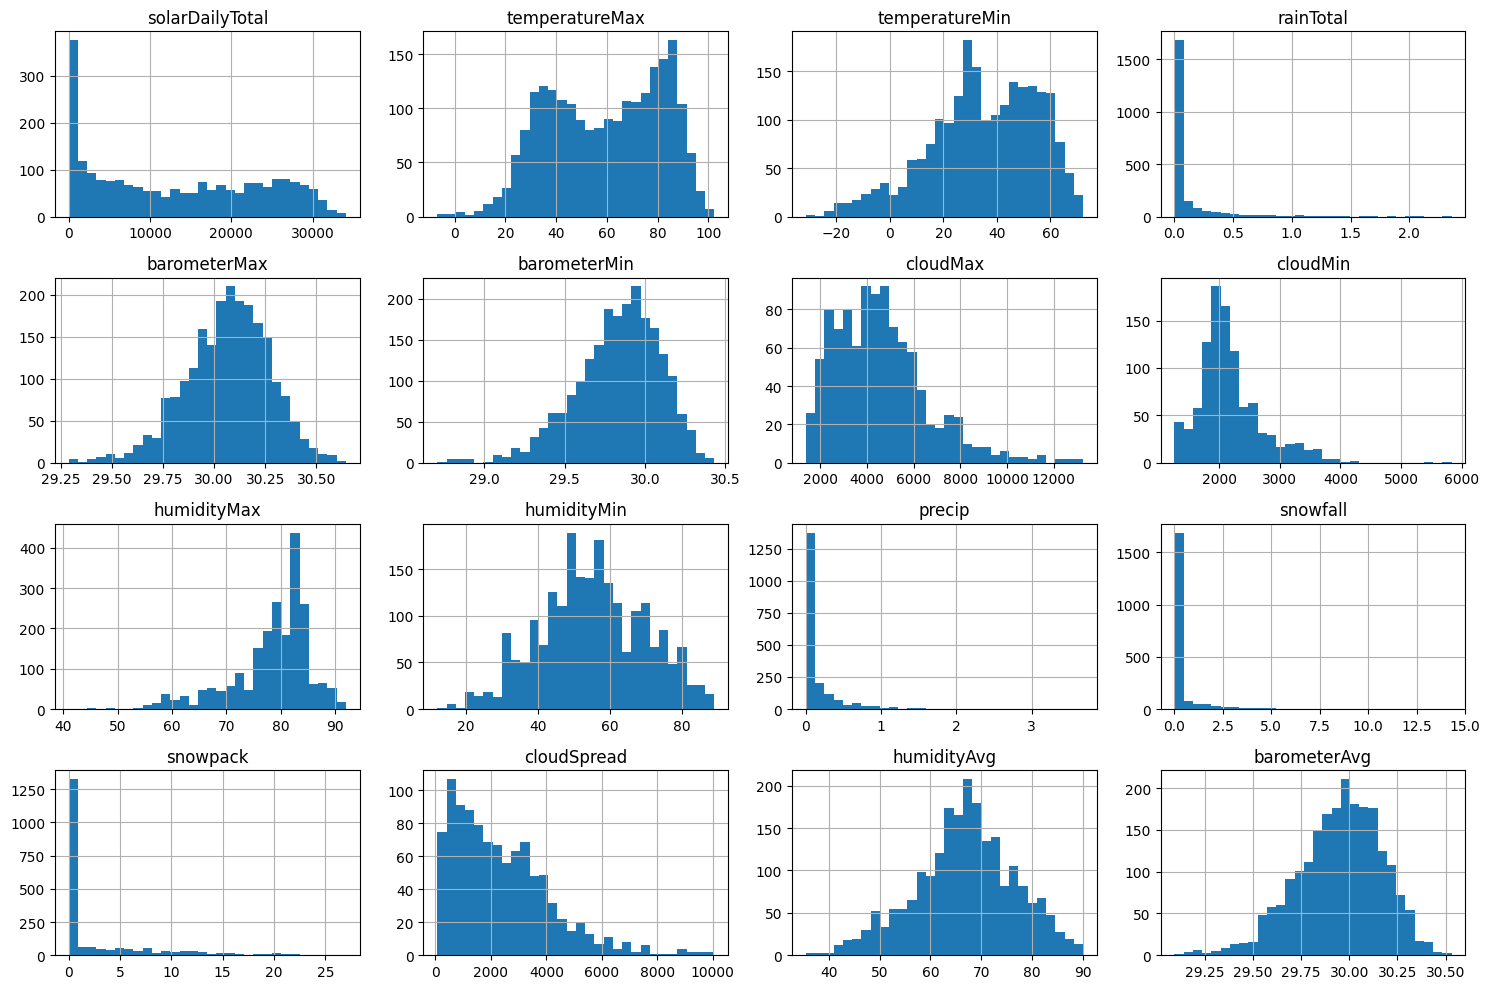

In [16]:
numeric_cols = ['solarDailyTotal', 'temperatureMax', 'temperatureMin', 'rainTotal',
                'barometerMax', 'barometerMin', 'cloudMax', 'cloudMin',
                'humidityMax', 'humidityMin', 'precip', 'snowfall',
                'snowpack', 'cloudSpread', 'humidityAvg', 'barometerAvg']

solar_power[numeric_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

The distributions of the variables highlight variation in underlying atmospheric conditions. Solar energy production is right-skewed, indicating that most days generate low to moderate solar energy production with occasional higher production extremes. Several weather-related predictors, such as precipitation and snowfall, are also highly-skewed and zero-inflated, reflecting infrequent but intense weather events. In contrast, temperature and barometric pressure variables are more symmetrically distributed, suggesting more stable daily patterns.

### Heat Maps

Spearman was used for each of the heat maps because solarDailyTotal is right-skewed

#### Atmospheric variables against solar output correlation heatmap
A heatmap was created of the correlation of the variables to solarDailyTotal to examine which variables may be most valuable in predicting solar output.

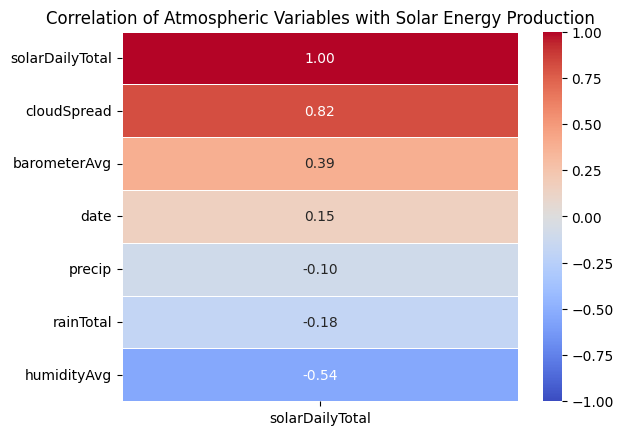

In [17]:
# correlation matrix
corr_matrix = atmo_solar.corr()

sns.heatmap(
    corr_matrix[['solarDailyTotal']].sort_values(by='solarDailyTotal', ascending=False),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidth=0.5
)

plt.title("Correlation of Atmospheric Variables with Solar Energy Production")
plt.show()

This heatmap shows the correlation between key atmospheric variables and daily solar energy production. Cloud spread has the strongest positive correlation with solar output (0.82), making it the mostly strongly correlated variable in the atmospheric dataset. Barometric pressure also shows a moderate psoitive relationship (0.39). In contrast, humidity is moderately negatively correlated (-0.54), indicating that higher humidity levels are associated with lower solar production. Precipitation and total rainfall have weak negative correlations (-0.10 and -0.18, respectively), suggesting a limited linear relationship with solar energy in this dataset. Overall, cloud height and humidity show the strongest relationships with solar energy production, while precipitation-related variables show weaker correlations.


#### Heat map comparing correlation between atmospheric predictors

In addition to exploring the correlation between individual predictors and solar output, I also wanted to explore the correlation amongst the predictors.

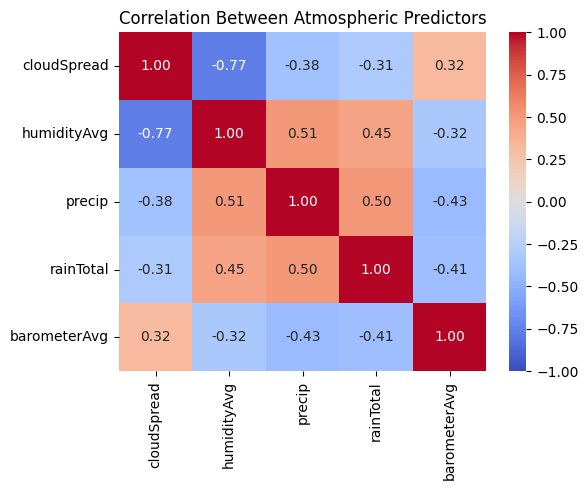

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(
    atmo_solar[['cloudSpread', 'humidityAvg', 'precip', 'rainTotal', 'barometerAvg']]
    .corr(method='spearman'),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f'
)

plt.title("Correlation Between Atmospheric Predictors")
plt.tight_layout()
plt.show()

Several moderate relationships are present, including strong negative correlation between cloud spread and humidity (-0.77), and moderate positive correlations between precipitation and rainfall (0.50), as well as between humidity and precipitation-related variables. These patterns suggest that multiple predictors capture overlapping atmospheric conditions, introducing potential multicollinearity.

#### Cloud-specific correlation heatmap

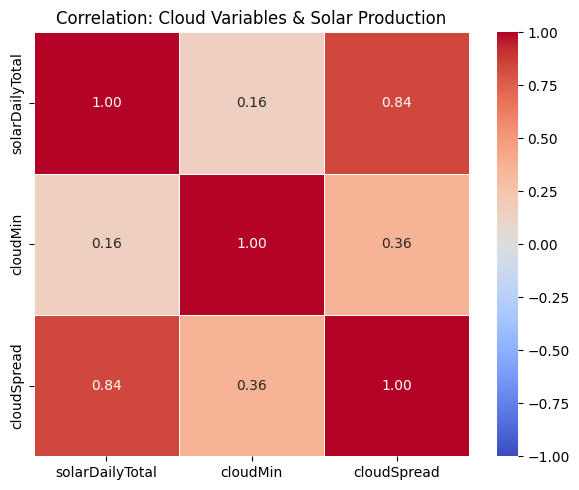

In [19]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cloud_solar[['solarDailyTotal', 'cloudMin', 'cloudSpread']].corr(method='spearman'),
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    annot=True,
    fmt='.2f',
    linewidth=0.5
)

plt.title('Correlation: Cloud Variables & Solar Production')
plt.tight_layout()
plt.show()

As shown in the correlation heatmap, cloud spread has a strong positive relationship with solar production (0.84), while minimum cloud height is only weakly correlated (0.16), which suggets that the vertical spread of clouds is a far more meaningful driver of daily output than how high (in altitude) the cloud base sits!

#### Snow correlation heatmap

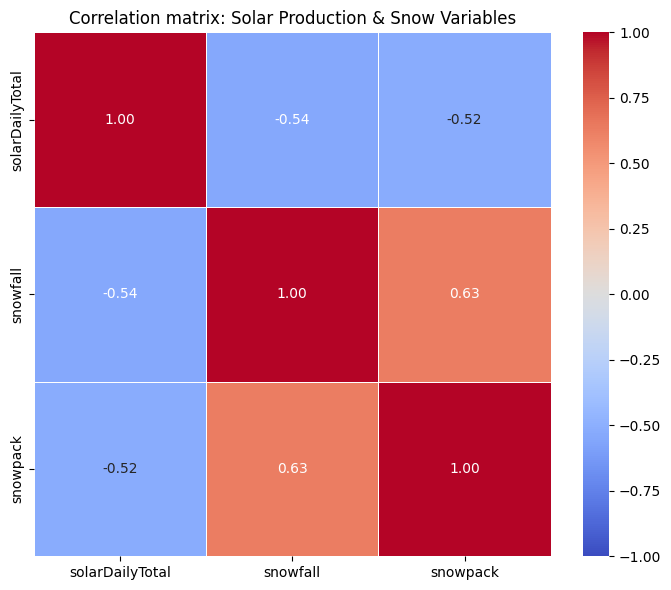

In [20]:
# make heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    snow_solar_analysis[['solarDailyTotal', 'snowfall', 'snowpack']].corr(method='spearman'),
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    annot=True,
    fmt='.2f',
    linewidth=0.5
)

plt.title('Correlation matrix: Solar Production & Snow Variables')

plt.tight_layout()
plt.show()

Both snow variables have moderate/strong negative correlations with solar production. Additionally, they are moderately correlated with one another, indicating some multicollinearity (i.e., days with new snowfall tend to have more snowpack, vice-versa), but not strong to the extent that a regression model would be destablized. This suggests LASSO is likely to prefer one predictor over the other when penalized.

*Note: Moderate/strong negative correlation between snowpack and solar production indicates data doesn't support hypothesis that snowpack increases production via reflected light.*


### Scatterplots

#### Atmospheric Effects

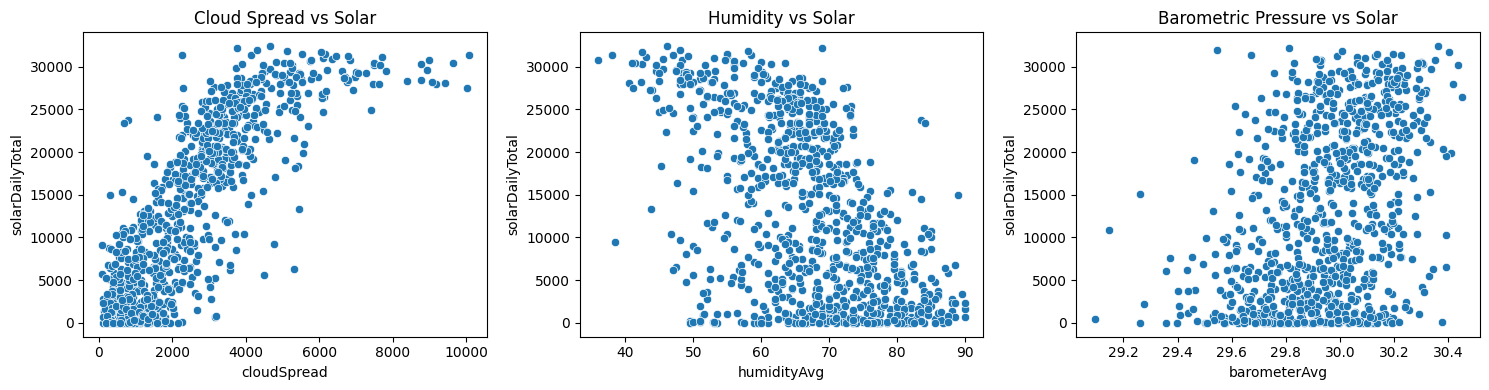

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(ax=axes[0], x='cloudSpread', y='solarDailyTotal', data=atmo_solar)
axes[0].set_title("Cloud Spread vs Solar")

sns.scatterplot(ax=axes[1], x='humidityAvg', y='solarDailyTotal', data=atmo_solar)
axes[1].set_title("Humidity vs Solar")

sns.scatterplot(ax=axes[2], x='barometerAvg', y='solarDailyTotal', data=atmo_solar)
axes[2].set_title("Barometric Pressure vs Solar")

plt.tight_layout()
plt.show()

The scatterplots reinforce patterns observed in the correlation analysis. Cloud spread shows a strong positive relationship with solar production, with higher values consistently associated with increased output. In contrast, humidity exhibits a negative trend, though with more variability, suggesting it plays a secondary but still meaningful role. Barometric pressure shows a weaker and less structured relationship, indicating it may contribute less predictive value on its own.



#### Cloud-Specific

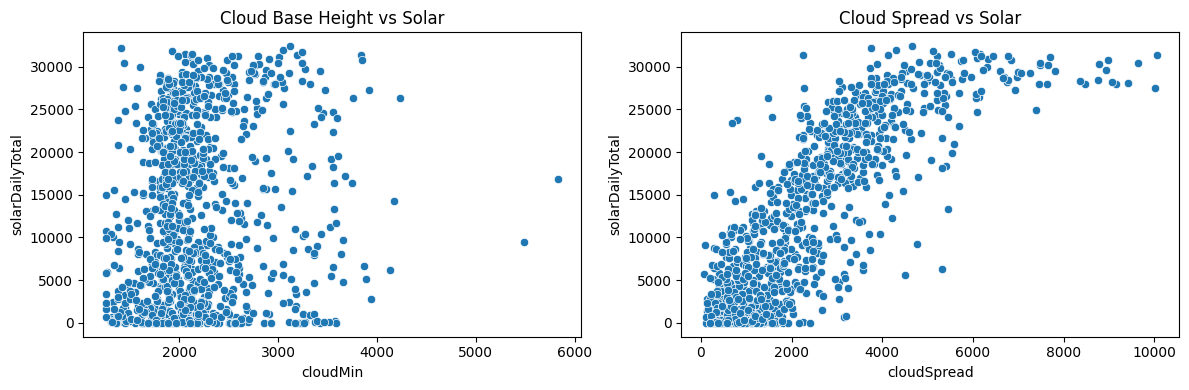

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(ax=axes[0], x='cloudMin', y='solarDailyTotal', data=cloud_solar)
axes[0].set_title("Cloud Base Height vs Solar")

sns.scatterplot(ax=axes[1], x='cloudSpread', y='solarDailyTotal', data=cloud_solar)
axes[1].set_title("Cloud Spread vs Solar")

plt.tight_layout()
plt.show()

To dig deeper into cloud-related patterns, we looked at cloud base height (cloudMin) against solar production alongside the cloud spread relationship already explored above. The cloud base height plot shows a positive relationship: days with very low cloud ceilings tend to have suppressed solar output, while higher ceilings are associated with generally higher, though more variable, production. This makes sense for this dataset, as clouds sitting closer to the surface are more likely to block incoming sunlight. Together, cloudMin and cloudSpread capture two distinct but complementary aspects of cloud structure: where clouds begin and how much of the atmosphere they span.

#### Snow Effects

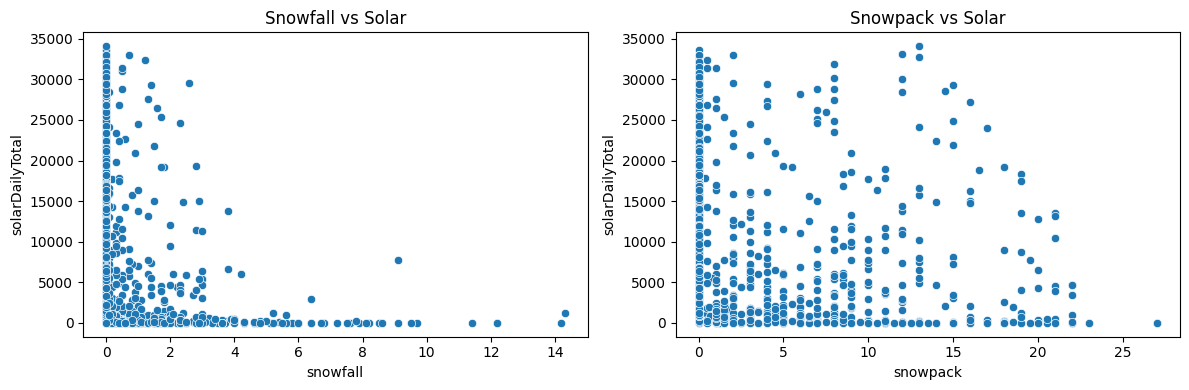

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(ax=axes[0], x='snowfall', y='solarDailyTotal', data=snow_solar_analysis)
axes[0].set_title("Snowfall vs Solar")

sns.scatterplot(ax=axes[1], x='snowpack', y='solarDailyTotal', data=snow_solar_analysis)
axes[1].set_title("Snowpack vs Solar")

plt.tight_layout()
plt.show()

Similar to atmospheric conditions, scatterplots for snowfall and snowpack reflect patterns observed in the correlation analysis. Active snowfall displays a moderate/strong negative relationship with solar production, and values above a trace amount often correspond to near-zero solar production. While snowpack has a similar overall negative correlation, it's relationship with solar production contains much more variability. This indicates that while snowpack generally accompanies lower production, the latter does not drop as steeply as under active snowfall (i.e., snowpack doesn't act as a 'hard limit' on solar production to the extent snowfall does).  

# **Machine Learning**


We divided our overall analysis into the following questions:
1. How do atmospheric conditions affect solary energy production?
2. How much does cloud cover reduce daily solar energy production?
3. How do snowfall and snowpack depth affect solar energy production?
4. Which weather variable has the strongest relationship with solar energy output?


We will tackle the machine learning processes step by step.

## Question 1: How do atmospheric conditions affect solar energy production?


**LASSO regression** was used to identify which atmospheric variables most strongly relate to solar energy production while accounting for overlap between predictors. Many of the weather variables in this dataset demonstrate correlation with each other. In particular, my heatmap completed in the EDA section shows that cloud spread and humidity have a moderately strong negative correlation (-0.77). We also see moderate correlations between humidity and precipitation (0.51) and precipitation and rain total (0.50). This creates multicollinearity, which can make standard linear regression unstable and make it harder to interpret individual coefficients.

LASSO addresses this issue by applying a penalty that shrinks less important coefficients toward zero, allowing the model to prioritize the most informative variables while reducing the importance of redundant ones. Since the goal of our question is not just prediction, but also understanding which atmospheric factors matter most, LASSO was a better approach than ordinary regression

In [24]:
# establish predictors
predictors = ['cloudSpread', 'humidityAvg', 'precip', 'rainTotal', 'barometerAvg']

X = atmo_solar[predictors].copy()
y = atmo_solar['solarDailyTotal']

X = X.dropna()
y = y[X.index]

# standarize variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


lasso = LassoCV(cv=5, random_state=3870)
lasso.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Variable': predictors,
    'Coefficient': lasso.coef_
})

print("Optimal alpha:", lasso.alpha_)
print(coef_df.sort_values(by='Coefficient', key=abs, ascending=False))

Optimal alpha: 8.321096749196933
       Variable  Coefficient
0   cloudSpread  9405.839629
1   humidityAvg  2064.249169
4  barometerAvg  1666.077139
2        precip  1012.231727
3     rainTotal  -690.700610


#### Chart the Results

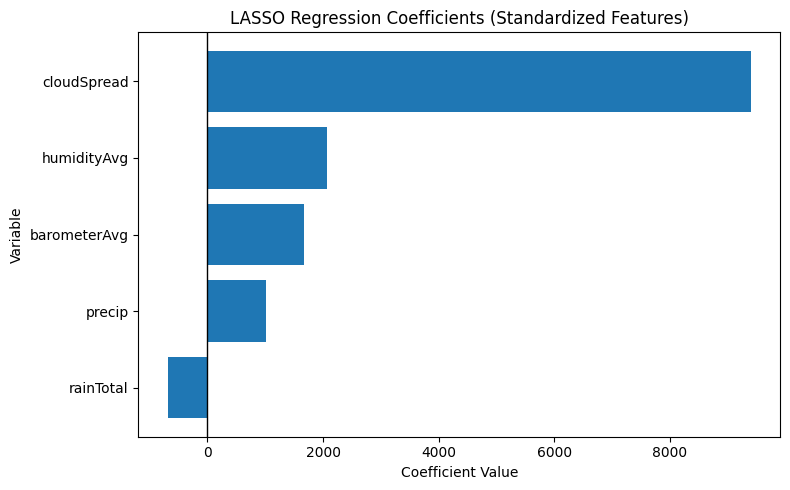

In [25]:
coef_df = coef_df.sort_values(by='Coefficient')

plt.figure(figsize=(8,5))

plt.barh(coef_df['Variable'], coef_df['Coefficient'])

plt.title('LASSO Regression Coefficients (Standardized Features)')
plt.xlabel('Coefficient Value')
plt.ylabel('Variable')

plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

LASSO supports our EDA's initial suggestion that cloud structure is the most informative atmospheric feature in predicting solar output, while humidity and barometric pressure have smaller, overlapping effects. Rain total is negative, which is intuitive because more rainfall generally means less sunlight. However, the magnitude of rain total is smaller than the other predictors, suggesting that it does not add much additional explanatory power beyond the other atmospheric variables already included in the model.

We used LASSO regression with the intention of performing feature selection among the correlated atmospheric predictors. Given the overlap between variables such as cloud height, humidity, and precipitation, we expected some coefficients to shrink toward zero. The fact that no variables were eliminated suggests the dataset does not contain extreme redundancy among these predictors after feature engineering, but rather that these variables may be capturing related, yet distinct, aspects of the same underlying process. In the context of solar energy production, one plausible source of this shared structure is seasonal variation, which influences both solar exposure and atmospheric conditions throughout the year. This motivates further investigation into the role of seasonality in explaining solar output.

#### Investigating seasonal impacts

Set up to include season for LASSO. We create seasons by pulling the month from the data.

In [26]:
season_lasso = atmo_solar.copy()

# creating season variable
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

season_lasso['season'] = season_lasso['date'].dt.month.apply(get_season)

#### One hot encoding for LASSO
We need to one hot encode our new seasons variable because LASSO requires numeric variables

In [27]:
# create encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# fit season
season_encoded = encoder.fit_transform(season_lasso[['season']])

# make df
season_df = pd.DataFrame(
    season_encoded,
    columns=encoder.get_feature_names_out(['season'])
)

# merge back into dataset
season_lasso = pd.concat([atmo_solar.reset_index(drop=True), season_df], axis=1)

#### Perform LASSO

In [28]:
X = season_lasso.drop(columns=['solarDailyTotal', 'date'])
y = season_lasso['solarDailyTotal']

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# re run lasso
lasso_season = LassoCV(cv=5, random_state=3870)
lasso_season.fit(X_scaled, y)

coef_df_season = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': lasso_season.coef_
})

print("Optimal alpha:", lasso_season.alpha_)
coef_df_season.sort_values(by='Coefficient', key=abs, ascending=False)

Optimal alpha: 58.70369257394792


,Variable,Coefficient
0,cloudSpread,7381.083136
6,season_Summer,1990.425647
7,season_Winter,-1591.236150
3,rainTotal,-1073.342788
4,barometerAvg,1037.370540
2,precip,768.450554
1,humidityAvg,617.684417
5,season_Spring,0.000000


In [29]:
comparison = pd.merge(
    coef_df.rename(columns={'Variable': 'Variable', 'Coefficient': 'Original'}),
    coef_df_season.rename(columns={'Coefficient': 'With Season'}),
    on='Variable',
    how='outer'
)

comparison

,Variable,Original,With Season
0,barometerAvg,1666.077139,1037.370540
1,cloudSpread,9405.839629,7381.083136
2,humidityAvg,2064.249169,617.684417
3,precip,1012.231727,768.450554
4,rainTotal,-690.700610,-1073.342788
5,season_Spring,NaN,0.000000
6,season_Summer,NaN,1990.425647
7,season_Winter,NaN,-1591.236150


After introducing seasonal variables using one-hot encoding, several atmospheric predictors decrease in magnitude. Cloud spread remains the strongest predictor of solar energy production, but its coefficient drops from 9405.84 to 7381.08, suggesting that part of its original effect was capturing seasonal variation in cloud patterns.

Humidity shows a large reduction (2064.25 to 617.68), indicating it is strongly tied to seasonal structure rather than independent daily variation. Barometric pressure and precipitation also decline, reinforcing that these variables partially reflect broader seasonal weather patterns.

In contrast, rain total becomes more strongly negative (-690.70 to -1073.34), suggesting a clearer inverse relationship with solar production once seasonality is accounted for.

The seasonal indicators behave as expected: summer is strongly positive (1990.43) and winter is strongly negative (-1591.24), confirming that seasonal structure is a major driver of solar energy variability, while spring serves as the baseline.

Overall, the results show that while cloud conditions remain the most important atmospheric predictor, several other variables partially capture seasonal effects rather than independent weather variation.


## Question 2: How much does cloud cover reduce daily solar energy production?
I decided to use **Multiple Linear Regression** because our goal is to directly estimate how much cloud cover affects daily solar production. Since both cloudMin and cloudSpread are continuous quantitative predictors and solarDailyTotal is a continuous quantitative response, MLR gives us straightforward, interpretable coefficient estimates. So, it tells us how many Wh of solar production are lost (or gained) for each unit change in a cloud variable, which is exactly the kind of answer we're looking for here.

Unlike LASSO, which shrinks coefficients as a tradeoff for handling multicollinearity, MLR gives us unpenalized estimates that are easier to interpret when the goal is quantifying an effect rather than selecting features. Importantly, the cloud-specific EDA heatmap showed that cloudMin and cloudSpread are only moderately correlated, so multicollinearity isn't a concern that would make MLR unstable here. We used an 80/20 train/test split and residual diagnostics to evaluate how well the model fits and whether its key assumptions hold.


##

In [30]:
# establish x and y
X_cloud = cloud_solar[['cloudMin', 'cloudSpread']]
y_cloud = cloud_solar['solarDailyTotal']

# train the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cloud, y_cloud, test_size=0.2, shuffle=True, random_state=3870
)

# fit the data
cloud_mlr = LinearRegression()
cloud_mlr.fit(X_train_c, y_train_c)

coef_df = pd.DataFrame({
    'Feature'    : X_cloud.columns,
    'Coefficient': cloud_mlr.coef_
})

print('Intercept:', round(cloud_mlr.intercept_, 2))
print(coef_df)

Intercept: 5122.5
       Feature  Coefficient
0     cloudMin    -1.723518
1  cloudSpread     4.773374


In [31]:
# scale to per 1000 ft so the numbers are easier to interpret
for _, row in coef_df.iterrows():
    print(f"Every 1,000 ft increase in {row['Feature']} → "
          f"{round(row['Coefficient'] * 1000, 1)} Wh change in daily solar production")

r2_train_c = round(cloud_mlr.score(X_train_c, y_train_c), 3)
r2_test_c  = round(cloud_mlr.score(X_test_c,  y_test_c),  3)
print(f'R2 (train): {r2_train_c}')
print(f'R2 (test):  {r2_test_c}')


Every 1,000 ft increase in cloudMin → -1723.5 Wh change in daily solar production
Every 1,000 ft increase in cloudSpread → 4773.4 Wh change in daily solar production
R2 (train): 0.679
R2 (test):  0.667


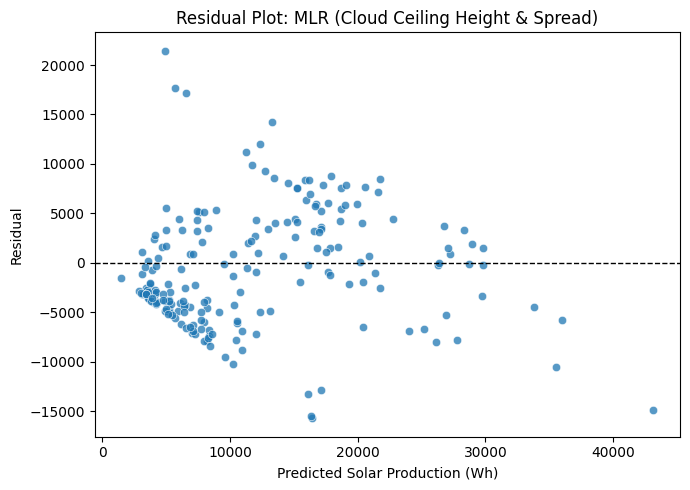

In [32]:
# residual plot
y_hat_c = cloud_mlr.predict(X_test_c)
res_c   = y_test_c.values - y_hat_c

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_hat_c,
    y=res_c,
    alpha=0.75
)

plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.title('Residual Plot: MLR (Cloud Ceiling Height & Spread)')
plt.xlabel('Predicted Solar Production (Wh)')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

The residual plot shows a clear pattern of heteroskedasticity. At low predicted production values the residuals are tightly clustered, but as predicted values increase they fan out much more in both directions. On low-production days, heavy cloud cover is likely the dominant factor driving output down, so the model does a decent job. But on higher-production days, other things like humidity, temperature, and seasonality start to matter more, and since those aren't included in this model, the predictions get less reliable. The dense cluster of negative residuals at the low end also suggests the model tends to slightly overpredict on days with very low cloud ceilings. Overall, while cloud structure is clearly an important predictor, the heteroskedasticity here confirms that cloud variables alone do not fully explain the patterns with daily solar output.

## Question 3: How do snowfall and snowpack depth affect solar energy production?

**Multiple Linear Regression** was used because our goal is to estimate the effect of multiple continuous numeric predictors (snowfall and snowpack depth) on a continuous numeric response variable (daily solar production) simultaneously. As our EDA indicates the predictor variables are not correlated to the extent where the resulting multicolinearity would destablize a linear regression model, MLR is an apt and easily-interpretable method to estimate the change in solar production associated with changes in snowfall and snowpack.

The snow_solar_analysis dataframe was used so that we're investigating the presence of (persistent or fresh) impacts solar production as compared to a winter day without snow.



#### Snow vs. No-Snow Days
A initial logical comparison to make is whether days with any measurable recorded snowfall produce less solar energy than days without.



In [33]:
# create dummy variable `snow_day` for whether any measurable snowfall
snow_solar_analysis['snow_day'] = np.where(
    snow_solar_analysis['snowfall'] > 0,
    'Snow day',
    'No snow'
)

# look at counts
snow_solar_analysis['snow_day'].value_counts()

,count
snow_day,
No snow,761
Snow day,398


Out of 1159 total days with valid data during months with persistent snowpack, 398 had recorded snowfall and 761 did not.


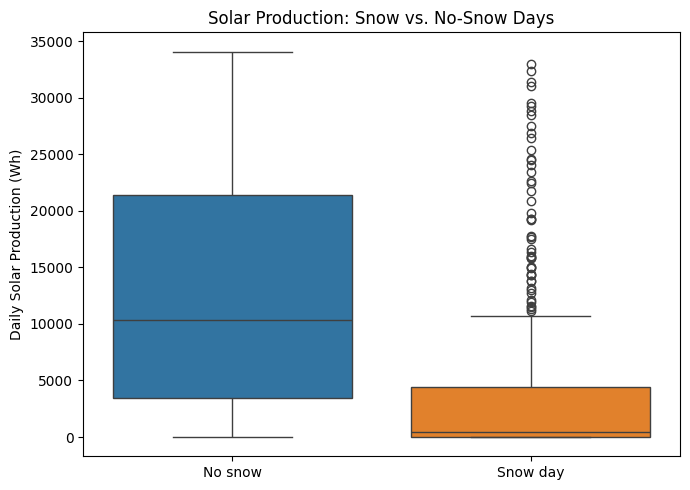

In [34]:
# make a box plot to visualize
plt.figure(figsize=(7, 5))

sns.boxplot(
    snow_solar_analysis,
    x='snow_day',
    y='solarDailyTotal',
    hue='snow_day'
)

plt.title('Solar Production: Snow vs. No-Snow Days')
plt.ylabel('Daily Solar Production (Wh)')
plt.xlabel('')
plt.tight_layout()
plt.show()

The box plot shows a substantial difference in solar production between days with and without recorded snowfall. Days without snow (“No snow”) have a higher median solar production (~10k Wh) and a wide interquartile range, suggesting high variability likely driven by other weather variables. On the other hand, ‘Snow days’ have a median solar production close to zero, and the majority of observations are concentrated at the bottom.

That said, the presence of multiple, relatively high-value outliers in the ‘Snow day’ category suggests that snowfall doesn’t guarantee low solar production. This variance is likely owed to the timing of the weather producing the snowfall (e.g., snow accumulates overnight followed by a high-pressure/sunny day, or by warming temps causing snow to melt off the panel).

#### MLR

In [35]:
# grab features
X_snow = snow_solar_analysis[['snowfall', 'snowpack']]
# and target
y_snow = snow_solar_analysis['solarDailyTotal']

# do 80/20 train/test split (w/ seed set for reproducibility)
X_train_snow, X_test_snow, y_train_snow, y_test_snow = train_test_split(X_snow, y_snow, test_size=.2, shuffle=True, random_state=3870)

# start the 'engine'
snow_solar_mlr = LinearRegression()

# fit the model
snow_solar_mlr.fit(
    X=X_train_snow,
    y=y_train_snow
)

# evaluate - coefficients
snow_solar_mlr_coeff = pd.DataFrame({
    'feature': X_snow.columns,
    'estimate': snow_solar_mlr.coef_
})

snow_solar_mlr_coeff


,feature,estimate
0,snowfall,-1144.091636
1,snowpack,-459.522814


In [36]:
# evaluate - R2
r2_train = round(snow_solar_mlr.score(X_train_snow, y_train_snow), 3)
r2_test = round(snow_solar_mlr.score(X_test_snow, y_test_snow), 3)

print(f"R2 (train): {r2_train}")
print(f"R2 (test): {r2_test}")

R2 (train): 0.143
R2 (test): 0.105


Both coefficients are negative as expected; more snowfall and deeper snowpack both predict less solar production.

The R2 (10.5%) is about what should be expected given the moderate correlations we saw earlier, and supports the idea that while the snow variables are relevant predictors, a large portion of variation in solar production is driven by other factors not included in the model.

The moderate drop between train and test R2's indicates the model is higher variance (i.e., slightly overfit) than is optimal, and the low R2 values indicate it's heavily biased as well.

Let's take a look at the residuals.

In [37]:
# calculate residuals
y_hat_snow = snow_solar_mlr.predict(X=X_test_snow)
res_snow = y_test_snow.values - y_hat_snow

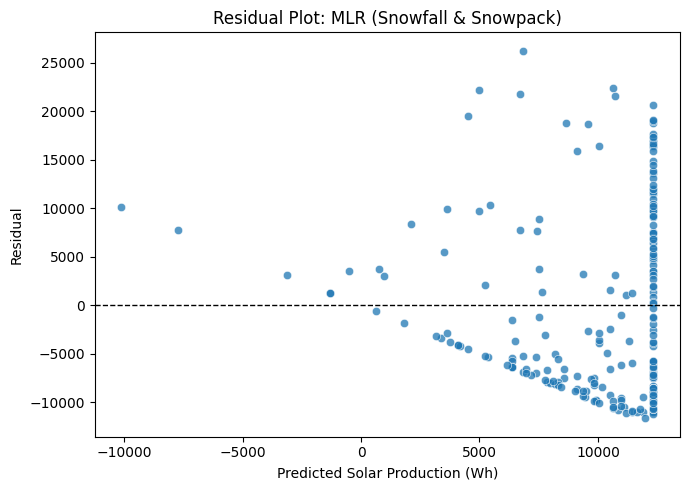

In [38]:
# make residual plot to check mlr assumptions & conditions
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_hat_snow,
    y=res_snow,
    alpha=0.75
)

plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.title('Residual Plot: MLR (Snowfall & Snowpack)')
plt.xlabel('Predicted Solar Production (Wh)')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

The clear hetereoskedasticity in the residual plot makes sense given the high density of low production on snowdays and the wide spread on non-snow days earlier observed. As snow variables are the only predictors, the model predicts ~12k Wh for any non-snow day (resulting in the dense stack of points at ~12k Wh), while actual production varies widely from factors not included in the model.

The hetereoskedasticity (errors growing larger at higher predicted production values) supports the notion that while snow variables do negatively impact solar production, they're insufficient alone to explain the variance on days with high-production. To address this unmodeled variance, we need to add additional atmospheric/weather predictors (e.g., cloud cover) and employ more robust modeling techniques.



## Question 4: Which weather variable has the strongest relationship with solar energy production?

Our EDA reveals that all weather variables have some relationship with solar production. However, as these variables are often highly correlated, they cannot be effectively evaluated individually / in isolation. Further, as demonstrated by the heteroskedasticity in the MLR model above, a simple linear model using only a subset of predictors doesn't effectively capture the complexity of these relationships. To identify a single strongest predictor, we will use two distinct methods: LASSO regularization and OLS regression to isolate and evaluate linear effects, and Random Forest regression to capture non-linear interactions. Feature importance metrics will then be compared and evaluated to answer our question.

**LASSO regularization was used because** adding more predictors to address unmodeled variance (heteroskedasticity) observed in earlier models increases the risk of multicollinearity and overfitting (high model variance). As observed in our EDA, many weather variables are highly correlated, potentially destabilizing standard linear regression coefficients. LASSO helps to mitigate this risk via penalization that 'pushes' coefficients of redundant or less informative predictors towards zero, enabling feature selection and identification of the weather variables with the strongest linear relationships with solar production while avoiding an overly complex model.

**Random Forests were used because** relationships between some weather variables and solar production may be non-linear, making linear regression insufficient for evaluating the strength of these relationships. Where normal decision trees are prone to being high-variance, and bagged trees can yield highly-correlated predictions, Random Forests reduce model variance while keeping bias low by creating a 'forest' (ensemble) of decision trees that consider a random subset of our weather variables at each split point. Lastly, RFs' feature_importances_ offer a metric with which we can compare LASSO coefficients to select the strongest weather predictor.

#### Seasonality

Before modeling, we need to account for the natural correlations between some weather variables (e.g., temperatureMax) and time of year. To isolate daily weather effects from seasonal shifts, let’s use the seasonal indicator variables we created earlier (see Q1) in our predictor set.

In [39]:
# use get_season from Q1
strongest_solar['season'] = strongest_solar['date'].dt.month.apply(get_season)

# OHE using Q1 encoder
season_encoded = encoder.transform(strongest_solar[['season']])

# make season df (match index!)
season_df = pd.DataFrame(
    season_encoded,
    columns=encoder.get_feature_names_out(['season']),
    index=strongest_solar.index
)

# check worked as expected (fall is baseline)
season_df.tail()

,season_Spring,season_Summer,season_Winter
2177,0.0,1.0,0.0
2178,0.0,1.0,0.0
2179,0.0,1.0,0.0
2180,0.0,1.0,0.0
2181,0.0,1.0,0.0


In [40]:
# combine weather vars w/ season vars to form final predictors
X_strongest = pd.concat([strongest_solar[weather_vars], season_df], axis=1)

# and grab target
y_strongest = strongest_solar['solarDailyTotal']

In [41]:
# do 80/20 train/test split for both (w/ class seed for reproducibility)
X_train_strongest, X_test_strongest, y_train_strongest, y_test_strongest = train_test_split(X_strongest, y_strongest, test_size=.2, shuffle=True, random_state=3870)

#### Standardization
Weather variables are in varying units, so comparing coefficients estimated from their 'as-is' values wouldn't be informative/helpful. To resolve this and enable comparison of effect size, we standardize the weather variables...

In [42]:
# start engine
scaler = StandardScaler()

# fit scaler for X_train_strongest's mean/sd
scaler.fit(X_train_strongest)

# make scaled train df
X_train_strongest_scaled = (
    pd.DataFrame(
        scaler.transform(X_train_strongest),
        columns = X_train_strongest.columns
    )
)

# verify via mean / sd
pd.DataFrame({
    'mean': X_train_strongest_scaled.mean(axis=0).round(5),
    'sd': X_train_strongest_scaled.std(axis=0)
})

,mean,sd
temperatureMax,-0.0,1.000791
temperatureMin,0.0,1.000791
rainTotal,-0.0,1.000791
barometerAvg,0.0,1.000791
cloudSpread,0.0,1.000791
humidityAvg,-0.0,1.000791
precip,0.0,1.000791
snowfall,0.0,1.000791
snowpack,0.0,1.000791
season_Spring,0.0,1.000791


In [43]:
# make scaled test df
X_test_strongest_scaled = (
    pd.DataFrame(
        scaler.transform(X_test_strongest),
        columns = X_test_strongest.columns
    )
)

# check mean / sd (not 0 / 1 like w/ train set)
pd.DataFrame({
    'mean': X_test_strongest_scaled.mean(axis=0).round(5),
    'sd': X_test_strongest_scaled.std(axis=0)
})

,mean,sd
temperatureMax,0.05097,1.000125
temperatureMin,0.09500,0.906624
rainTotal,0.00484,0.935818
barometerAvg,-0.11620,1.006320
cloudSpread,0.01426,0.941440
humidityAvg,0.08467,0.977926
precip,0.02448,1.226391
snowfall,-0.00165,0.860422
snowpack,0.01455,1.062143
season_Spring,-0.04616,0.975364


#### LASSO Regularization (w/ CV)

Let's use 10-fold cross-validation (via LassoCV) on the train set of standardized weather variables to identify the best value of lambda to avoid overfitting.

In [44]:
# setup folds
cv_folds = RepeatedKFold(
    n_splits = 10,
    n_repeats = 10,
    random_state = 3870
)

In [45]:
# run grid search w/ LassoCV over ~5k values and fit
lasso_search_strongest = (
    LassoCV(
        alphas = np.arange(.01, 50, .01),
        cv = cv_folds,
        n_jobs = -1 # all cores!
    )
    .fit(
        X = X_train_strongest_scaled,
        y = y_train_strongest
    )
)

Let's visualize the rmse at the ~5k different values of lambda to confirm a true minimum was found...

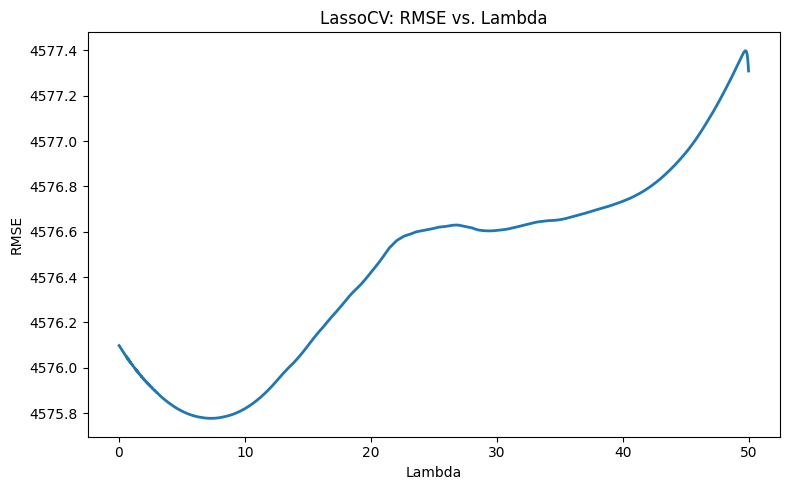

In [46]:
# visualize results
plt.figure(figsize=(8, 5))
plt.plot(
    lasso_search_strongest.alphas,
    # flip rmse order
    np.flip(np.sqrt(lasso_search_strongest.mse_path_.mean(axis=1))),
    linewidth=2
)
plt.title('LassoCV: RMSE vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

There is a clear minimum in rmse at approximately lambda=7. Let's see what the precise value is....

In [47]:
# best choice of lambda is...
print(f'Best choice of lambda is {lasso_search_strongest.alpha_: .1f}')

Best choice of lambda is  7.3


In [48]:
# identify which predictors LASSO kept
lasso_strongest_results = (
  pd.DataFrame({
      'feature': X_train_strongest_scaled.columns,
      'estimate': lasso_search_strongest.coef_
      })
  # filter out feature w/ coeffs of 0
  .query('estimate != 0')
)

lasso_strongest_results

,feature,estimate
0,temperatureMax,4971.425963
1,temperatureMin,-2703.978302
2,rainTotal,-1401.187495
3,barometerAvg,817.268525
4,cloudSpread,4923.208814
5,humidityAvg,295.410944
6,precip,1260.441993
7,snowfall,-726.656010
8,snowpack,119.012582
9,season_Spring,451.311014


All predictors were kept, which could be attributed to the use of engineered features (e.g., barometerAvg, cloudSpread, humidityAvg) as opposed to their constituent parts, which were shown earlier to display multicollinearity.

#### Linear Regression
Let's use these features in a linear regression model to understand differences in effect size without penalization.

In [49]:
remaining_features = lasso_strongest_results['feature'].tolist()

In [50]:
strongest_mlr = (
    LinearRegression()
    # fit with train set
    .fit(
        X = X_train_strongest_scaled[remaining_features],
        y = y_train_strongest
    )
)

In [51]:
# evaluate - coefficients
strongest_mlr_coeff = (
  pd.DataFrame({
      'feature': X_train_strongest_scaled[remaining_features].columns,
      'estimate': strongest_mlr.coef_
  })
  .sort_values(
      by='estimate',
      ascending=False
  )
)

strongest_mlr_coeff

,feature,estimate
0,temperatureMax,5051.649537
4,cloudSpread,4938.137629
10,season_Summer,1336.015032
6,precip,1274.212043
3,barometerAvg,825.366534
9,season_Spring,477.323571
5,humidityAvg,363.711504
8,snowpack,131.148145
7,snowfall,-743.038477
11,season_Winter,-1122.526693


The weather variables with the strongest relationship with solar production are temperatureMax (+), cloudSpread (+), and temperatureMin (-).

Let's evaluate the model to confirm how much of the variance in solar production is explained by the weather variables...

In [52]:
# evaluate - R2
r2_train_strongest = round(strongest_mlr.score(X_train_strongest_scaled[remaining_features], y_train_strongest), 3)
r2_test_strongest = round(strongest_mlr.score(X_test_strongest_scaled[remaining_features], y_test_strongest), 3)

print(f"R2 (train): {r2_train_strongest}")
print(f"R2 (test): {r2_test_strongest}")

R2 (train): 0.806
R2 (test): 0.835


<Figure size 800x600 with 0 Axes>

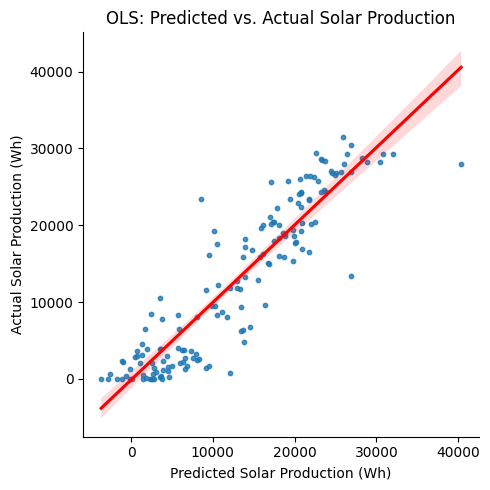

In [53]:
# visualize via R2 plot:
plt.figure(figsize=(8, 6))
sns.lmplot(
    pd.DataFrame({
        'y': y_test_strongest,
        'y_hat': strongest_mlr.predict(
            X = X_test_strongest_scaled[remaining_features]
        )
    }),
    x='y_hat',
    y='y',
    line_kws={'color': 'red'},
    scatter_kws={'s': 10}
)

plt.title('OLS: Predicted vs. Actual Solar Production')
plt.xlabel('Predicted Solar Production (Wh)')
plt.ylabel('Actual Solar Production (Wh)')

plt.tight_layout()
plt.show()

The linear model gives a R2 of 0.835 on the test set, indicating ~83.5% of variance in solar production is successfully explained. The relatively small of difference between train and test R2 values (0.806 vs. 0.835) demonstrates LASSO prevented the model from overfitting.

#### Random Forests

Next, let's use random forests to understand the importance of weather variables with non-linear relationships with solar production...

In [54]:
# define dict for grid search
hyper_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 400, 500],
    'max_features': np.arange(1, 11, 1).tolist(),
    'max_depth': [1, 2, 10, 20, 50, None]
}

In [55]:
# setup folds for 10-fold CV
cv10 = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 3870
)

In [56]:
# setup search
strongest_rand_search = RandomizedSearchCV(
    ensemble.RandomForestRegressor(random_state = 3870),
    param_distributions = hyper_grid,
    n_iter = 100,
    cv = cv10,
    random_state = 3870,
    n_jobs = -1 # all cores!
)

In [57]:
# time search
start = time.time()

# train {x} models
strongest_rand_search.fit(X_train_strongest_scaled, y_train_strongest)

# stop timer and print search time
end = time.time()

print(f'Search time: {end-start: .3f} sec.')

Search time:  282.978 sec.


In [58]:
# evaluate
print(f'Best params: {strongest_rand_search.best_params_}')

Best params: {'n_estimators': 300, 'max_features': 4, 'max_depth': 50}


The results of our search show the best hyperparameters for our Random Forest are building 300 trees, using 4 features per tree, and growing 2^50 leaf nodes.

In [59]:
print(f'Forest from random search has an R2 of: {strongest_rand_search.best_estimator_.score(X_test_strongest_scaled, y_test_strongest): .3f}')

Forest from random search has an R2 of:  0.873


The tuned Random Forest's R2 of ~0.873 is small improvement over the linear model's ~0.835, which suggests non-linear relationships (and other interactions) play a role in predicting solar production.

Now that we've tuned our Random Forest, let's use it to compare the strength (i.e., feature importance) of our weather variables...

In [60]:
feat_imp_strongest = (
    pd.DataFrame({
        'feature': X_test_strongest_scaled.columns,
        'importance': strongest_rand_search.best_estimator_.feature_importances_
    })
    .sort_values(
        by='importance',
        ascending=False
    )
)

feat_imp_strongest

,feature,importance
4,cloudSpread,0.435634
0,temperatureMax,0.210536
5,humidityAvg,0.087527
11,season_Winter,0.056800
1,temperatureMin,0.052954
2,rainTotal,0.036619
8,snowpack,0.035939
3,barometerAvg,0.031611
6,precip,0.020809
7,snowfall,0.014485


cloudSpread is by far the most important feature in our Random Forest model, and temperatureMax and humidityAvg don't fall far behind.

#### Comparing Results

Now that we have unpenalized coefficients (LASSO / OLS regression) and feature importances (Random Forest), let's calculate the relative importance of the former so we can compare to the latter.   

In [61]:
# take absolute value of OLS coefficients
strongest_mlr_coeff['estimate_abs'] = strongest_mlr_coeff['estimate'].abs()

# calculate sum of absolute values
ols_total_effect = strongest_mlr_coeff['estimate_abs'].sum()

# divide each coefficient's absolute value by this sum
strongest_mlr_coeff['ols_importance'] = strongest_mlr_coeff['estimate_abs'] / ols_total_effect

# sort by this relative importance
strongest_mlr_coeff.sort_values(
    by='ols_importance',
    ascending=False
)

,feature,estimate,estimate_abs,ols_importance
0,temperatureMax,5051.649537,5051.649537,0.246466
4,cloudSpread,4938.137629,4938.137629,0.240928
1,temperatureMin,-2819.739345,2819.739345,0.137573
2,rainTotal,-1413.456479,1413.456479,0.068961
10,season_Summer,1336.015032,1336.015032,0.065183
6,precip,1274.212043,1274.212043,0.062168
11,season_Winter,-1122.526693,1122.526693,0.054767
3,barometerAvg,825.366534,825.366534,0.040269
7,snowfall,-743.038477,743.038477,0.036252
9,season_Spring,477.323571,477.323571,0.023288


Now let's combine both OLS and Random Forest importances into the same df for comparison!

In [62]:
# grab just feature names and importances
ols_imp = strongest_mlr_coeff[['feature', 'ols_importance']]

rf_imp = (
  feat_imp_strongest[['feature', 'importance']]
  .rename(columns={'importance': 'rf_importance'}) # rename to distinguish from ols importance
)

# merge into new df on feature; sort by random forest feature importance
ols_vs_rf = (
    pd.merge(
        ols_imp,
        rf_imp,
        on='feature'
    )
    .sort_values(
        by='rf_importance',
        ascending=False
    )
)

ols_vs_rf

,feature,ols_importance,rf_importance
1,cloudSpread,0.240928,0.435634
0,temperatureMax,0.246466,0.210536
6,humidityAvg,0.017745,0.087527
9,season_Winter,0.054767,0.056800
11,temperatureMin,0.137573,0.052954
10,rainTotal,0.068961,0.036619
7,snowpack,0.006399,0.035939
4,barometerAvg,0.040269,0.031611
3,precip,0.062168,0.020809
8,snowfall,0.036252,0.014485


To visualize how these importances compare, we must reshape the data into long format.

In [63]:
ols_vs_rf_melt = (
    ols_vs_rf
    .melt(
        id_vars = 'feature',
        value_vars = ['ols_importance', 'rf_importance'],
        var_name = 'model',
        value_name = 'rel_importance'
    )
)

# confirm melt worked as expected
ols_vs_rf_melt

,feature,model,rel_importance
0,cloudSpread,ols_importance,0.240928
1,temperatureMax,ols_importance,0.246466
2,humidityAvg,ols_importance,0.017745
3,season_Winter,ols_importance,0.054767
4,temperatureMin,ols_importance,0.137573
5,rainTotal,ols_importance,0.068961
6,snowpack,ols_importance,0.006399
7,barometerAvg,ols_importance,0.040269
8,precip,ols_importance,0.062168
9,snowfall,ols_importance,0.036252


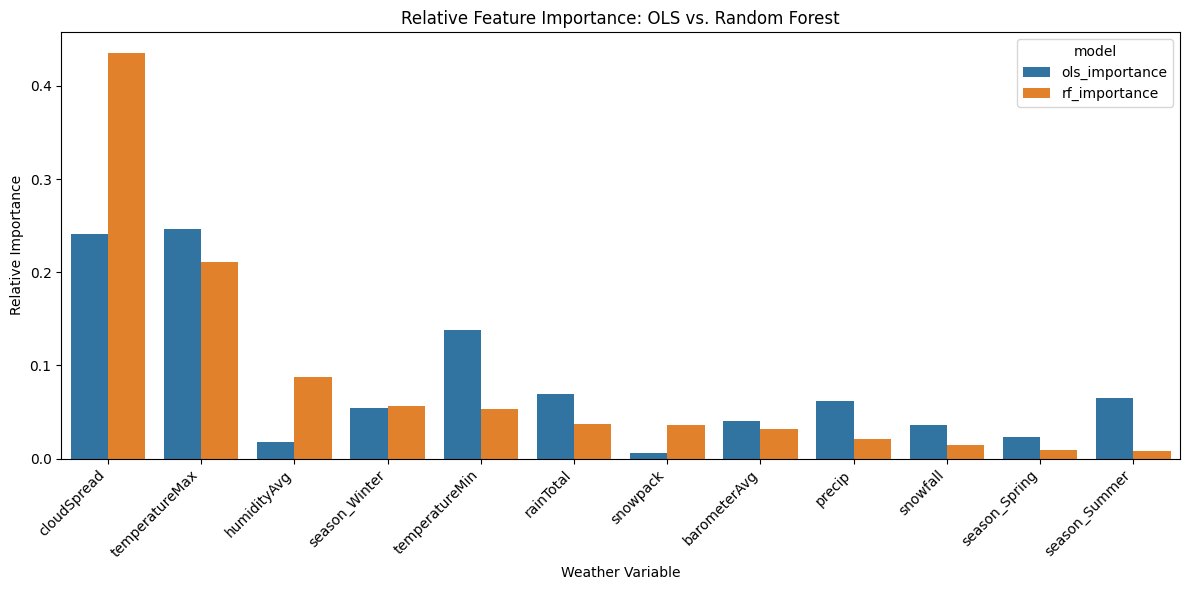

In [64]:
plt.figure(figsize=(12, 6))
sns.barplot(
    ols_vs_rf_melt,
    x='feature',
    y='rel_importance',
    hue='model'
)

plt.title('Relative Feature Importance: OLS vs. Random Forest')
plt.xlabel('Weather Variable')
plt.ylabel('Relative Importance')

# rotate xaxis labels 45 degrees
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Comparing the relative importances between linear (OLS) and non-linear (Random Forest) models reveals interesting insights.

Cloud spread is dominant predictor in both models, indicating that it's the weather variable with the strongest relationship to solar production. However, the Random Forest gives more relative importance to cloudSpread (44% vs. 24%) and less to temperatureMax (22% vs. 25%) than the linear model. Further, weather variables like humidityAvg and snowpack have higher importance in the Random Forest model, suggesting their effects on solar production are non-linear (e.g., snowpack impacts solar production only when actively blocking panels, as opposed to reducing production linearly across all possible depth values).

# Summary and Conclusions

Our analysis was successful in modeling factors that impact solar energy production. Through answering our four main questions, we came to the following conclusions:

**Impacts of atmospheric variables are heavily tied to seasonality.**
While humidity and barometric pressure are correlated with solar output, introducing one-hot encoded seasonal variables into our LASSO regression showed that much of their predictive power can actually be owed to seasonal shifts (e.g., winter vs. summer), as opposed to isolated, day-to-day weather conditions.

**Cloud structures have a complex relationship with solar production.**
Our linear model revealed that clouds do impact production, but the relationship isn’t straightforward. For instance, we found that a 1000 ft. increase in vertical cloud spread boosts solar production by ~4773 Wh. High values of cloud spread likely indicate low-density cloud formations that allow sunlight to penetrate and drive solar production, whereas low values likely indicate dense formations that block sunlight and reduce solar production. However, raising the minimum cloud height by 1000 ft. reduces solar production by ~1724 Wh, further illustrating how cloud structure has significant and complex effects.

**Snowfall and snowpack reduce solar production.**
Our analysis disproved the hypothesis that snowpack could increase solar production via reflected light, with both snowpack and snowfall shown to have a negative impact. Snowfall puts an immediate and significant penalty on production (often dropping to nearly zero), whereas snowpack acts as a secondary and highly-variable penalty that lowers production without acting as a ‘hard limit’ like the former.

**Cloud spread and maximum temperature are the strongest predictors.**
When comparing all weather variables against one another in a linear model, cloud spread a nd maximum temperature had nearly equivalent contributions, with each accounting for ~20-25% of the model’s total predictive power. When utilizing a Random Forest model to capture potential non-linear relationships, however, cloud spread was clearly the primary predictor, accounting for ~44% of the model’s total predictive power. The Random Forest model also revealed that variables like humidity and snowpack are much stronger predictors when their non-linear dynamics (e.g., snow accumulating and remaining on panels, acting as an ‘on’/’off’ threshold on production as opposed to a consistent linear penalty) are accounted for with an appropriate non-linear method.

**Overall Takeaway**

Overall, these findings show that solar energy production is shaped by a more complex and dynamic set of factors than we initially assumed, with seasonality and cloud structure playing particularly larger roles. This project allowed us to reflect on how we thought environmental conditions would affect solar energy production. One example of this in our project, our data disproved our expectation that that snowpack could actually boost production by reflecting light was directly disproven, showing that real-world weather effects are not always what they seem!

# Limitations and Recommendations for future work
**Single-location data**

 The entire dataset comes from one installation site, which limits how broadly we can apply our findings. Solar production dynamics vary significantly by latitude, altitude, panel orientation, and local climate, so results from a snowy northern climate, particularly anything involving snowfall and snowpack, may not hold in drier or warmer regions. Future work could address this by running the same procedures on data collected from multiple locations across different climates.

**Missing documentation on data collection**
 The dataset was originally collected by a past student from four separate sources. We have limited visibility into how the solar energy readings were recorded, whether sensors were properly calibrated across the full 2017 to 2023 period, or whether any recording gaps or quality issues exist in the raw data. Not having the notation, documentation, or specs for how this data was recorded is our biggest limitation. We did external research to ensure we were using the data correctly, which became especially important when working with the cloud cover variables. Initially we interpreted cloudMin and cloudMax as how much of the sky was covered by clouds on a horizontal plane.

 After running into results that didn't make sense or hold up consistently, we pivoted and looked into how cloud data is actually recorded. This led us to realize that cloudMin and cloudMax represent the minimum and maximum altitude of cloud cover, not horizontal coverage. From there, we used the spread between those two values to capture how much cloud cover was present in the atmosphere. That said, cloudSpread is still an indirect proxy, what physically matters for solar production is how much of the sky is actually covered and how optically thick the clouds are. There is also a possibility that there are other misinterpretations in our data that we were not able to catch. Future work should prioritize using datasets that come with clear documentation and variable definitions to avoid these issues.

**Loss of intraday information through aggregation**

Solar energy is measured every 15 minutes but aggregated to daily totals for this analysis. A morning storm followed by a clear afternoon would produce a very different daily total than the reverse, yet both would look identical in our dataset. Future work could address this by modeling at the hourly level(opposed to daily), which would likely reveal patterns that get lost through daily aggregation.

**Unmodeled external factors**

 Several factors known to affect solar production were simply not available in our dataset, including panel soiling from dust or debris, physical shading from nearby trees or structures, panel degradation over the multi-year observation window, and the specific tilt and orientation of the panels. Without these variables, other predictors like temperature or season may be absorbing some of their effects. If that information were included in our dataset, we could better isolate the effect of weather conditions without other factors muddying the results.

**Heteroskedasticity in regression models**

The residual plots for both the snow and cloud MLR models show heteroskedasticity, meaning the spread of residuals increases at higher predicted values. This violates a core assumption of OLS regression. Coefficient estimates remain unbiased, but standard errors become unreliable.

**LASSO assumes approximate normality**

 LassoCV relies on mean squared error loss, which implicitly assumes normally distributed residuals. Since solarDailyTotal is right-skewed and has a lot of near-zero values on low-production days, this assumption is not fully met. A log transformation or quantile regression approach may produce more reliable coefficient estimates and would be worth exploring.

**Correlation does not imply causation**

 All of our models are observational, so the associations we identify between weather variables and solar production cannot be interpreted as causal. For example, the positive association between temperature and solar production most likely reflects shared seasonal structure rather than temperature directly boosting panel output. Experimental or quasi-experimental designs, while difficult in this context, would be needed to make stronger causal claims.
